In [ ]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# Técnicas para valores faltantes

## Librerías y configuración

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Librerías listas para usarse.")

Librerías listas para usarse.


## Ignorar la tupla

### Carga la base de datos

In [7]:
# Leer el archivo CSV
df = pd.read_csv('AirQualityUCI.csv')

print("¡Datos cargados correctamente!")

¡Datos cargados correctamente!


### Procedimiento

In [7]:
# 1. CARGA CORRECTA: Le decimos a Python que separe por ';' y que los decimales son ','
df = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",")

# 2. LIMPIEZA DE ARCHIVO: Quitamos columnas y filas que el Excel/CSV crea en blanco al final
df = df.dropna(how='all', axis=1)
df = df.dropna(how='all', axis=0)

# 3. TRUCO DEL SENSOR: Convertimos los -200 (datos falsos/faltantes) a nulos reales
df = df.replace(-200, np.nan)

# 4. TÉCNICA: Ignorar la tupla (borramos las filas que tengan al menos un nulo)
df_limpio = df.dropna().reset_index(drop=True)

# 5. Mostrar resultados
print("Tamaño final tras ignorar todas las tuplas incompletas:", df_limpio.shape)
display(df_limpio.head())

Tamaño final tras ignorar todas las tuplas incompletas: (827, 15)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Asignar el valor faltante

### Cargar la base de datos y asignar nombres a las columnas

In [8]:
# 1. Nombres de las columnas (traducidos y simplificados para tu reporte)
nombres_cols = [
    "ID", "Clump_Thickness", "Cell_Size_Uniformity", "Cell_Shape_Uniformity", 
    "Marginal_Adhesion", "Single_Epi_Cell_Size", "Bare_Nuclei", 
    "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"
]

# 2. Leer la base de datos (header=None porque el archivo no trae títulos)
df_cancer = pd.read_csv("breast-cancer-wisconsin.data", header=None, names=nombres_cols)

### Procedimiento

In [9]:
# 3. Detectar los '?' y convertirlos en valores nulos reales (NaN)
df_cancer = df_cancer.replace('?', np.nan)

# Verificamos cuántos nulos hay antes de rellenar
print("Nulos ANTES de la asignación manual:")
print(df_cancer.isna().sum()[df_cancer.isna().sum() > 0])

# 4. TÉCNICA: Asignación manual del valor faltante (Asignamos el 1)
valor_conveniente = 1
df_cancer['Bare_Nuclei'] = df_cancer['Bare_Nuclei'].fillna(valor_conveniente)

# 5. Opcional pero recomendado: Convertir la columna a número entero (estaba como texto por culpa de los '?')
df_cancer['Bare_Nuclei'] = df_cancer['Bare_Nuclei'].astype(int)

# Verificamos que ya no haya nulos
print("\nNulos DESPUÉS de la asignación manual:")
print(df_cancer.isna().sum().sum()) # Debería imprimir 0

display(df_cancer.head())

Nulos ANTES de la asignación manual:
Bare_Nuclei    16
dtype: int64

Nulos DESPUÉS de la asignación manual:
0


,ID,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epi_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


## Usar una constante global para asignar valores faltantes

### Cargar la base de datos y asignar nombres a las columnas

In [10]:
# 1. Definimos los nombres de las columnas (basado en la documentación oficial del dataset)
nombres_autos = [
    "symboling", "normalized_losses", "make", "fuel_type", "aspiration",
    "num_doors", "body_style", "drive_wheels", "engine_location", "wheel_base",
    "length", "width", "height", "curb_weight", "engine_type", "num_cylinders",
    "engine_size", "fuel_system", "bore", "stroke", "compression_ratio",
    "horsepower", "peak_rpm", "city_mpg", "highway_mpg", "price"
]

# 2. Leemos la base de datos
df_autos = pd.read_csv("imports-85.data", header=None, names=nombres_autos)

### Procedimiento

In [11]:
# 3. Detectamos la trampa: convertimos los '?' en valores nulos (NaN)
df_autos = df_autos.replace('?', np.nan)

print("Nulos ANTES de aplicar la constante global:")
print(df_autos.isna().sum()[df_autos.isna().sum() > 0])

# 4. TÉCNICA: Asignar un valor mediante una Constante Global
# Elegimos "Desconocido" como nuestra constante global
constante_global = "Desconocido"
df_autos = df_autos.fillna(constante_global)

# 5. Verificamos los resultados
print("\nNulos DESPUÉS de aplicar la constante global:")
print(df_autos.isna().sum().sum()) # Debe ser 0

# Mostramos un ejemplo de las filas que tenían nulos para ver cómo quedó
display(df_autos.head())

Nulos ANTES de aplicar la constante global:
normalized_losses    41
num_doors             2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64

Nulos DESPUÉS de aplicar la constante global:
0


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,Desconocido,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,Desconocido,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,Desconocido,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Usar una medida de tendencia central para el atributo

### Cargar la base de datos

In [15]:
# 1. Leemos el archivo (sin nombres de columnas, asignará de 0 a 15)
df_credito = pd.read_csv("crx.data", header=None)

### Procedimiento

In [16]:
import pandas as pd
import numpy as np

# 1. Leemos el archivo (sin nombres de columnas, asignará de 0 a 15)
df_credito = pd.read_csv("crx.data", header=None)

# 2. Reemplazamos los '?' por nulos reales (NaN)
df_credito = df_credito.replace('?', np.nan)

print("Nulos ANTES de la técnica:")
print(df_credito.isna().sum()[df_credito.isna().sum() > 0])

# 3. Forzamos a Python a reconocer los números que confundió con texto
for col in df_credito.columns:
    try:
        df_credito[col] = pd.to_numeric(df_credito[col])
    except ValueError:
        pass # Si falla, significa que es una columna de letras reales, la dejamos en paz

# 4. TÉCNICA: Tendencia Central Doble (Mediana para números, Moda para texto)

# A) Rellenamos los números con la Mediana
cols_numericas = df_credito.select_dtypes(include=['number']).columns
df_credito[cols_numericas] = df_credito[cols_numericas].fillna(df_credito[cols_numericas].median())

# B) Rellenamos el texto con la Moda
cols_texto = df_credito.select_dtypes(exclude=['number']).columns
for col in cols_texto:
    moda_columna = df_credito[col].mode()[0] # [0] toma el valor más repetido
    df_credito[col] = df_credito[col].fillna(moda_columna)

print("\nNulos DESPUÉS de aplicar Mediana y Moda:")
print(df_credito.isna().sum().sum()) # ¡Debe dar 0!

display(df_credito.head())

Nulos ANTES de la técnica:
0     12
1     12
3      6
4      6
5      9
6      9
13    13
dtype: int64

Nulos DESPUÉS de aplicar Mediana y Moda:
0


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


## Usar el promedio o mediana del aatributo para todas las muestras pertenecientes a la misma clase

### Cargar la base de datos

In [17]:
# 1. Leemos la base de datos
df_garments = pd.read_csv("garments_worker_productivity.csv")

### Procedimiento

In [19]:
print("Nulos ANTES de la imputación:")
print(df_garments.isna().sum()[df_garments.isna().sum() > 0])

# 2. TÉCNICA PRINCIPAL: Mediana por clase (departamento)
df_garments['wip'] = df_garments.groupby('department')['wip'].transform(lambda x: x.fillna(x.median()))

# 3. TÉCNICA DE RESPALDO: Si un departamento entero estaba vacío (como 'finishing'), 
# su mediana fue NaN. Rellenamos esos casos especiales con 0.
df_garments['wip'] = df_garments['wip'].fillna(0)

print("\nNulos DESPUÉS de la imputación con respaldo:")
print(df_garments.isna().sum().sum()) # ¡Ahora sí debe dar 0!

display(df_garments.head())

Nulos ANTES de la imputación:
wip    506
dtype: int64

Nulos DESPUÉS de la imputación con respaldo:
0


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,0.0,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


# Técnicas de reducción de dimensionalidad

### PCA - Análisis de Componentes Principales

PCA es una técnica de reducción de dimensionalidad **lineal** que transforma los datos originales en un nuevo sistema de coordenadas donde las direcciones de mayor varianza se ordenan primero.

---

#### Algoritmo paso a paso

1. **Estandarización:** Se centra y escala cada variable (media=0, varianza=1), para que ninguna variable domine por su escala.
2. **Matriz de covarianza:** Se calcula para entender cómo se relacionan las variables entre sí.
3. **Eigendecomposición:** Se extraen los *eigenvectors* (direcciones) y *eigenvalues* (magnitud de varianza en esa dirección).
4. **Ordenamiento:** Los eigenvectors se ordenan de mayor a menor eigenvalue → estos son los **Componentes Principales**.
5. **Proyección:** Los datos originales se proyectan sobre los $k$ componentes seleccionados.

> Cada componente principal es una **combinación lineal** de las variables originales, y son **ortogonales** entre sí (independientes).

---

#### Hiperparámetros en scikit-learn

##### 1. `n_components`
Controla cuántas dimensiones conservas en la salida.

| Valor | Comportamiento |
|---|---|
| `int` (ej. `n_components=2`) | Mantiene exactamente N componentes |
| `float` entre 0 y 1 (ej. `0.95`) | Mantiene los componentes que expliquen ese % de varianza |
| `None` | Mantiene todos los componentes |
| `'mle'` | Usa estimación automática de Minka |

**Efecto:** A menor número de componentes, más información se pierde pero más compacta y simple es la representación. La elección clásica se hace con la **curva de varianza explicada acumulada**.

---

##### 2. `whiten`
- `False` *(default)*: Los componentes conservan la magnitud original (escala proporcional al eigenvalue).
- `True`: Normaliza cada componente para que tenga varianza unitaria.

**Cuándo usarlo:** Cuando vas a usar PCA como preprocesamiento para algoritmos sensibles a la escala (ej. SVM, redes neuronales).

---

##### 3. `svd_solver`
Define el algoritmo interno para calcular la descomposición:

| Valor | Cuándo es mejor |
|---|---|
| `'auto'` | Elige automáticamente según el tamaño |
| `'full'` | SVD completa, más precisa, lenta en datos grandes |
| `'randomized'` | Aproximación rápida para datos grandes y pocas componentes |
| `'arpack'` | Buena para matrices sparse y pocas componentes |

**Efecto:** `'randomized'` puede dar resultados ligeramente distintos por su naturaleza estocástica, controlable con `random_state`.

---

##### 4. `random_state`
Solo aplica cuando `svd_solver='randomized'`. Fija la semilla para reproducibilidad.

---

##### 5. `tol`
Tolerancia para la convergencia (solo con `svd_solver='arpack'`). Valores más bajos = más precisión, más lento.

---

#### Resumen del impacto de hiperparámetros

| Hiperparámetro | Impacto principal |
|---|---|
| `n_components` | Trade-off entre información retenida vs. complejidad |
| `whiten` | Normaliza la salida, útil como preprocesamiento |
| `svd_solver` | Velocidad vs. precisión según tamaño del dataset |
| `random_state` | Reproducibilidad con solver randomizado |
| `tol` | Precisión de convergencia con solver arpack |

---

#### Limitaciones importantes

- Solo captura **relaciones lineales** entre variables.
- **Sensible a outliers** (porque maximiza varianza).
- Los componentes son difíciles de interpretar en términos del dominio original.
- Requiere que los datos estén **estandarizados** previamente para funcionar bien.

### t-SNE (t-Distributed Stochastic Neighbor Embedding)

A diferencia de PCA, t-SNE es una técnica **no lineal** diseñada principalmente para la visualización de datos complejos.

---

#### Algoritmo

1. Para cada par de puntos en el espacio original, calcula una probabilidad conjunta $p_{ij}$ que refleja qué tan *vecinos* son usando una **distribución Gaussiana**.
2. En el espacio reducido (2D/3D), define probabilidades $q_{ij}$ usando una **distribución t de Student** con 1 grado de libertad. Esta distribución de cola pesada resuelve el problema de aglomeración que tenía SNE original.
3. Minimiza la **divergencia de Kullback-Leibler** entre las distribuciones P y Q mediante descenso de gradiente.
4. El resultado es un embedding donde los clusters del espacio original quedan visualmente separados.

**Función objetivo:**

$$KL(P \| Q) = \sum_{ij} p_{ij} \cdot \log\left(\frac{p_{ij}}{q_{ij}}\right)$$

---

#### Hiperparámetros de t-SNE

| Hiperparámetro | Valor típico | Efecto en el resultado |
|---|---|---|
| `perplexity` | 5 – 50 (default `30`) | Controla el balance entre estructura local y global. Valores bajos se enfocan en vecindades muy pequeñas (detalle local); valores altos consideran vecindades más amplias (contexto global). Debe ser menor al número de puntos. **Afecta dramáticamente la forma visual del resultado.** |
| `n_iter` | 1000 – 5000 (default `1000`) | Número de iteraciones de descenso de gradiente. Pocas iteraciones pueden no converger; más iteraciones mejoran la estabilidad del embedding pero aumentan el tiempo de cómputo. |
| `learning_rate` | 10 – 1000 (default `200`) | Tamaño del paso en el descenso de gradiente. Valores muy altos generan embeddings con clusters comprimidos al centro; valores muy bajos producen embeddings uniformes sin estructura. `'auto'` lo calibra automáticamente. |
| `early_exaggeration` | 4 – 100 (default `12`) | Multiplica las probabilidades $p_{ij}$ en la fase inicial para crear clusters más compactos. Valores altos producen clusters más separados y compactos. |
| `metric` | `'euclidean'`, `'cosine'`, `'manhattan'`... | Define la función de distancia en el espacio original. `'cosine'` es útil para datos de texto; `'euclidean'` para datos numéricos continuos. Cambia fundamentalmente qué se considera "similar". |
| `n_components` | `2` o `3` | Dimensión del embedding de salida. Casi siempre `2` para visualización; `3` para visualización interactiva 3D. |

# Preprocesamiento, limpieza y reducción de dimensionalidad

DATASET: IRIS
Técnica utilizada:      PCA
Dimensiones originales: 4 atributos
Dimensiones finales:    2 atributos
Reducción lograda:      50.0%
Varianza retenida:      95.8%



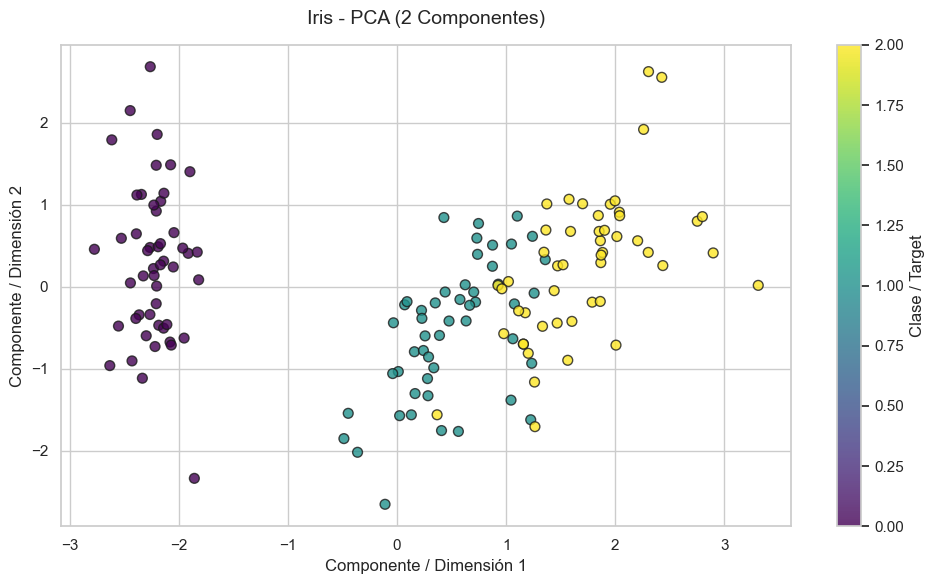

DATASET: BREAST CANCER
Técnica utilizada:      PCA
Dimensiones originales: 30 atributos
Dimensiones finales:    2 atributos
Reducción lograda:      93.3%
Varianza retenida:      63.2%



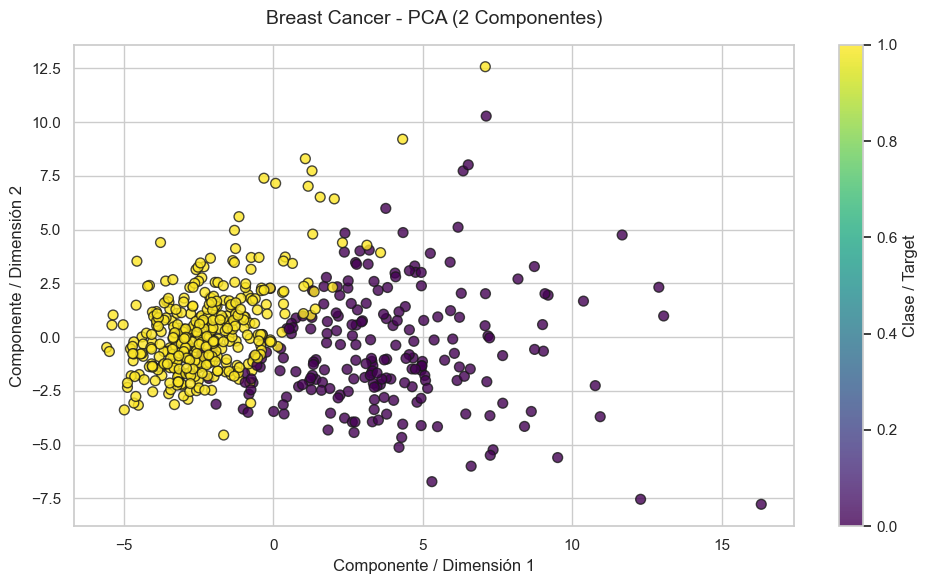

DATASET: WINE
Técnica utilizada:      TSNE
Dimensiones originales: 13 atributos
Dimensiones finales:    2 atributos
Reducción lograda:      84.6%
Varianza retenida:      No aplica (t-SNE preserva distancias, no varianza)



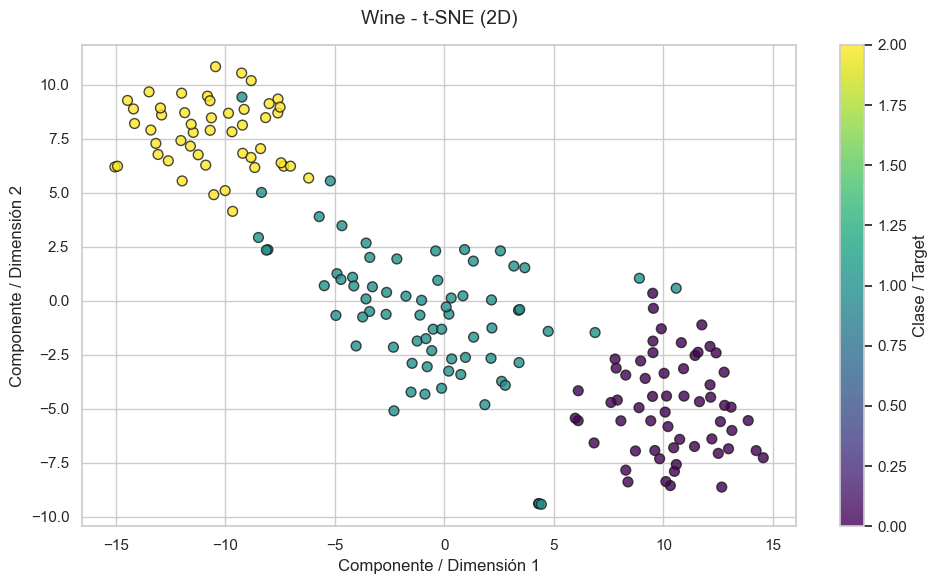

DATASET: DIGITS
Técnica utilizada:      TSNE
Dimensiones originales: 64 atributos
Dimensiones finales:    2 atributos
Reducción lograda:      96.9%
Varianza retenida:      No aplica (t-SNE preserva distancias, no varianza)



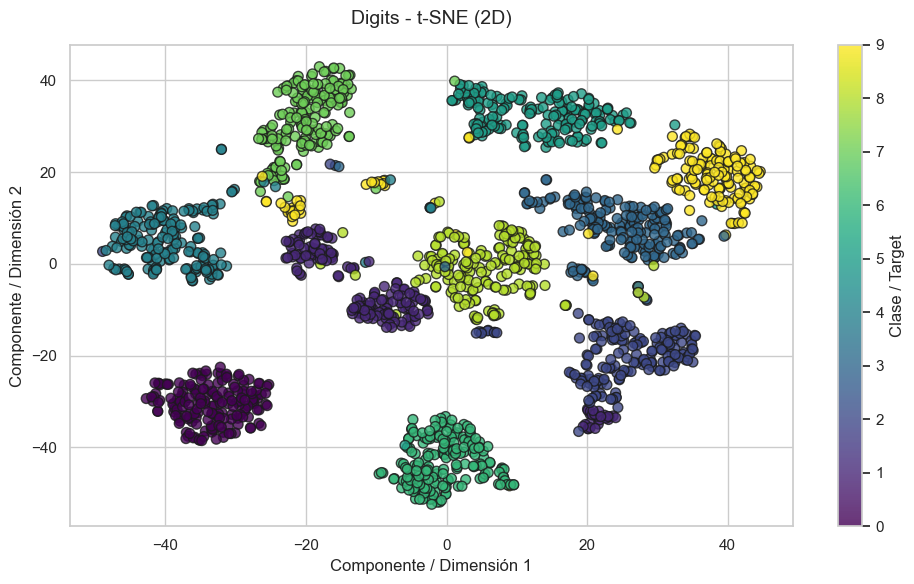

DATASET: CALIFORNIA HOUSING
Técnica utilizada:      PCA
Dimensiones originales: 8 atributos
Dimensiones finales:    2 atributos
Reducción lograda:      75.0%
Varianza retenida:      47.2%



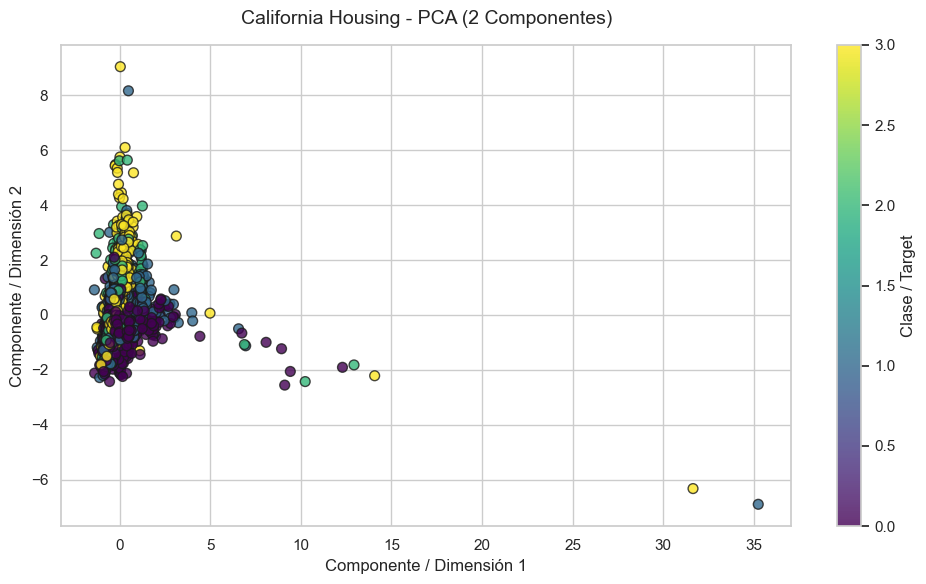

In [23]:
# Configuración de estilo para las gráficas
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

def procesar_imprimir_y_graficar(nombre, data_raw, target, tecnica='pca'):
    # 1. PREPROCESAMIENTO
    df = pd.DataFrame(data_raw)
    df = df.fillna(df.median())
    
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(df)
    dim_original = data_scaled.shape[1]
    
    # 2. REDUCCIÓN
    if tecnica == 'pca':
        model = PCA(n_components=2)
        puntos_reducidos = model.fit_transform(data_scaled)
        # Calculamos cuánta información se conservó (solo aplica para PCA)
        varianza_retenida = model.explained_variance_ratio_.sum() * 100
        info_extra = f"Varianza retenida:      {varianza_retenida:.1f}%"
        titulo = f"{nombre} - PCA (2 Componentes)"
    else:
        model = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
        puntos_reducidos = model.fit_transform(data_scaled)
        info_extra = "Varianza retenida:      No aplica (t-SNE preserva distancias, no varianza)"
        titulo = f"{nombre} - t-SNE (2D)"
        
    dim_nueva = puntos_reducidos.shape[1]
    
    # 3. IMPRIMIR DATOS EN CONSOLA
    print(f"{'='*45}")
    print(f"DATASET: {nombre.upper()}")
    print(f"Técnica utilizada:      {tecnica.upper()}")
    print(f"Dimensiones originales: {dim_original} atributos")
    print(f"Dimensiones finales:    {dim_nueva} atributos")
    print(f"Reducción lograda:      {((dim_original - dim_nueva) / dim_original) * 100:.1f}%")
    print(info_extra)
    print(f"{'='*45}\n")
    
    # 4. GRAFICAR
    plt.figure()
    scatter = plt.scatter(puntos_reducidos[:, 0], puntos_reducidos[:, 1], 
                          c=target, cmap='viridis', s=50, alpha=0.8, edgecolor='k')
    plt.title(titulo, fontsize=14, pad=15)
    plt.xlabel('Componente / Dimensión 1')
    plt.ylabel('Componente / Dimensión 2')
    plt.colorbar(scatter, label='Clase / Target')
    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---

# 1. Iris
iris = datasets.load_iris()
procesar_imprimir_y_graficar("Iris", iris.data, iris.target, 'pca')

# 2. Breast Cancer
cancer = datasets.load_breast_cancer()
procesar_imprimir_y_graficar("Breast Cancer", cancer.data, cancer.target, 'pca')

# 3. Wine
wine = datasets.load_wine()
procesar_imprimir_y_graficar("Wine", wine.data, wine.target, 'tsne')

# 4. Digits
digits = datasets.load_digits()
procesar_imprimir_y_graficar("Digits", digits.data, digits.target, 'tsne')

# 5. California Housing (Muestra pequeña)
housing = datasets.fetch_california_housing()
# Convertimos el target continuo en discreto (cuartiles) para que los colores se vean bien
housing_target_categorias = pd.qcut(housing.target[:2000], q=4, labels=False)
procesar_imprimir_y_graficar("California Housing", housing.data[:2000], housing_target_categorias, 'pca')

# Normalización

La normalización es un proceso de preprocesamiento de datos que consiste en ajustar los valores de las variables para que se encuentren dentro de una misma escala. Esto se hace porque en muchos conjuntos de datos las variables pueden tener rangos muy diferentes, lo que puede afectar el rendimiento de los algoritmos de análisis o aprendizaje automático.

Por ejemplo, en un dataset médico una variable como edad puede tener valores entre 0 y 100, mientras que niveles de glucosa pueden estar entre 70 y 200. Si no se normalizan los datos, las variables con valores más grandes pueden tener mayor influencia en el modelo, aunque no necesariamente sean más importantes.

## ¿Para qué sirve?

La normalización se utiliza principalmente para:

- Evitar que variables con valores grandes dominen el análisis.
- Mejorar el rendimiento de algoritmos de aprendizaje automático.
- Facilitar la convergencia de algoritmos de optimización.
- Permitir que los datos sean comparables entre sí.
- Mejorar la estabilidad numérica de algunos modelos.

Muchos algoritmos funcionan mejor cuando los datos se encuentran en rangos similares, especialmente aquellos que utilizan distancias o gradientes.

## ¿Cuándo usarse y cuándo no usarse?

### Cuándo usar normalización

Se recomienda usar normalización cuando:

- Los datos tienen diferentes escalas o unidades.
- Se utilizan algoritmos basados en distancia.
- Se aplican técnicas de reducción de dimensionalidad.
- Se usan métodos que dependen de gradientes.

Ejemplos de algoritmos donde la normalización es importante:

- K-Nearest Neighbors (KNN)
- Support Vector Machines (SVM)
- K-means
- Redes neuronales
- PCA

### Cuándo no es necesario usar normalización

No siempre es necesario normalizar los datos. Por ejemplo:

- En algoritmos basados en árboles de decisión.
- En Random Forest.
- En Gradient Boosting.

Estos modelos no dependen de distancias entre variables, por lo que la escala de los datos no afecta significativamente el resultado.

## Tipos de normalización más comunes

### 1. Normalización Min-Max

Transforma los datos para que queden dentro de un rango específico, generalmente entre 0 y 1.

**Fórmula:**

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Cuándo usarla:**

- Cuando se desea mantener la distribución original de los datos.
- Cuando los algoritmos requieren valores dentro de un rango específico.
- Muy usada en redes neuronales.

**Desventaja:** Es sensible a valores atípicos (outliers).

---

### 2. Estandarización (Z-score)

Transforma los datos para que tengan:

- media = 0
- desviación estándar = 1

**Fórmula:**

$$x' = \frac{x - \mu}{\sigma}$$

donde μ es la media y σ la desviación estándar.

**Cuándo usarla:**

- Cuando los datos tienen outliers.
- Cuando los algoritmos asumen una distribución aproximadamente normal.
- Muy usada en PCA, SVM y regresión logística.

---

### 3. Normalización robusta

Utiliza la mediana y el rango intercuartílico (IQR) en lugar de la media y la desviación estándar.

**Cuándo usarla:**

- Cuando el dataset tiene muchos valores atípicos.
- Cuando la distribución de los datos es muy asimétrica.

---

## Otros detalles importantes

- La normalización debe realizarse antes de entrenar un modelo.
- Si se divide el dataset en entrenamiento y prueba, los parámetros de normalización (media, desviación, mínimo, máximo) deben calcularse solo con los datos de entrenamiento.
- Es una etapa fundamental en el preprocesamiento de datos dentro del flujo de trabajo de ciencia de datos.
- La normalización también facilita la visualización y comparación de variables.

# Ejercicios p121-123
## Capítulo 3 — Preprocesamiento de Datos


---

## Exercise 3.1 — Calidad de Datos: Exactitud, Completitud y Consistencia

La evaluación de la calidad de los datos depende del uso que se le dará. Las tres dimensiones se manifiestan de forma diferente según el contexto:

### Exactitud (Accuracy)
La exactitud se refiere a si los valores de los datos reflejan correctamente las entidades del mundo real.
- **Contexto médico:** una presión arterial registrada de 80/50 mmHg puede ser exacta para un paciente crítico, pero podría indicar un error de captura en un chequeo de rutina. El uso previsto determina qué es "plausible".
- **Contexto minorista:** un precio de $0.01 puede ser un error de escaneo en datos de supermercado, pero podría ser válido para artículos en liquidación.

### Completitud (Completeness)
La completitud se refiere a si todos los datos requeridos están presentes.
- **Sistema de RRHH:** el campo "fecha de contratación" faltante es crítico para el cálculo de nómina, pero irrelevante para una búsqueda en el directorio.
- **E-commerce:** un número de teléfono faltante es aceptable para una transacción digital, pero obligatorio para un pedido de entrega.

### Consistencia (Consistency)
La consistencia se refiere a si los valores no presentan contradicciones entre atributos o tablas relacionadas.
- **Salud:** un registro con "fecha de alta" anterior a la "fecha de ingreso" es claramente inconsistente. Esto importa para facturación pero no para un conteo simple de pacientes.
- **Finanzas:** una transacción registrada en USD en una tabla y EUR en otra genera inconsistencia relevante en reportes multimoneda.

>  **Dos dimensiones adicionales de calidad de datos:**
> 1. **Puntualidad (Timeliness):** los datos deben ser suficientemente actuales para su uso previsto (ej. los precios de acciones de ayer son inútiles para trading en tiempo real).
> 2. **Credibilidad (Believability):** los datos deben ser confiables para quienes los usan, aunque sean técnicamente exactos (ej. datos de encuestas auto-reportados pueden estar registrados correctamente pero no ser creídos).

---

## Exercise 3.2 — Manejo de Valores Faltantes

Existen varios métodos para manejar tuplas con valores faltantes en algún atributo:

- **Ignorar la tupla:** descartar el registro completo. Simple pero ineficiente, especialmente cuando solo falta uno de muchos atributos. Apropiado únicamente cuando los datos faltantes son muy raros.
- **Rellenar manualmente:** un experto humano completa el valor faltante. Solo viable para datasets pequeños; no es escalable.
- **Usar una constante global:** reemplazar todos los valores faltantes con un centinela como "Desconocido" o −∞. Riesgo: introduce una nueva categoría espuria que puede confundir al algoritmo de minería.
- **Usar la media o moda del atributo:** reemplazar con la media (para numéricos) o moda (para nominales) del atributo en todas las tuplas. Rápido y simple, pero ignora correlaciones con otros atributos.
- **Usar la media condicional por clase:** usar el valor medio del atributo dentro de la misma etiqueta de clase. Más preciso que la media global porque tiene en cuenta la estructura de clases.
- **Usar el valor más probable (basado en inferencia):** usar regresión, redes bayesianas o árboles de decisión para predecir el valor faltante a partir de otros atributos. El más exacto, pero computacionalmente costoso.

---

## Exercise 3.3 — Suavizado, Outliers y Métodos de Suavizado

**Datos:** `13, 15, 16, 16, 19, 20, 20, 21, 22, 22, 25, 25, 25, 25, 30, 33, 33, 35, 35, 35, 35, 36, 40, 45, 46, 52, 70`

### (a) Suavizado por Medias de Bin — Profundidad de bin = 3

Los 27 valores se dividen en 9 bins de 3 valores cada uno. Cada valor se reemplaza por la media de su bin:

| Bin | Valores originales | Media del bin | Valores suavizados |
|---|---|---|---|
| 1 | 13, 15, 16 | 14.67 | 14.67, 14.67, 14.67 |
| 2 | 16, 19, 20 | 18.33 | 18.33, 18.33, 18.33 |
| 3 | 20, 21, 22 | 21.00 | 21.00, 21.00, 21.00 |
| 4 | 22, 25, 25 | 24.00 | 24.00, 24.00, 24.00 |
| 5 | 25, 25, 30 | 26.67 | 26.67, 26.67, 26.67 |
| 6 | 33, 33, 35 | 33.67 | 33.67, 33.67, 33.67 |
| 7 | 35, 35, 35 | 35.00 | 35.00, 35.00, 35.00 |
| 8 | 36, 40, 45 | 40.33 | 40.33, 40.33, 40.33 |
| 9 | 46, 52, 70 | 56.00 | 56.00, 56.00, 56.00 |

>  **Efecto:** La técnica reduce el ruido y la variación local. El outlier 70 se acerca hacia 56.00 y los valores extremos aislados se moderan. Con bin de tamaño 3 se preservan tendencias locales sin un suavizado excesivo.

### (b) ¿Cómo detectar outliers?
- **Método del boxplot:** valores fuera de $Q_1 - 1.5 \times IQR$ o $Q_3 + 1.5 \times IQR$ son outliers potenciales. Para estos datos: $Q_1 \approx 21$, $Q_3 \approx 35$, $IQR = 14$ → límite superior $= 35 + 21 = 56$. El valor **70 es un outlier**.
- **Método z-score:** valores con $|z| > 2$ o $3$ son outliers. Para 70: $z = (70 - 29.96) / 12.94 \approx 3.09$ → outlier.
- **Clustering:** puntos que no pertenecen a ningún cluster, o en clusters muy pequeños, se consideran outliers.

### (c) Otros métodos de suavizado de datos
- **Suavizado por límites de bin:** reemplazar cada valor por el límite más cercano del bin (mínimo o máximo).
- **Suavizado por medianas de bin:** reemplazar cada valor por la mediana del bin (más robusto ante outliers que la media).
- **Regresión:** ajustar una función de regresión lineal o no lineal a los datos y usar los valores de la función.
- **Clustering:** agrupar valores en clusters y reemplazar outliers o valores ruidosos con los centroides del cluster.

---

## Exercise 3.4 — Problemas en la Integración de Datos

La integración de datos combina datos de múltiples fuentes en un almacén coherente. Los problemas clave incluyen:

- **Problema de identificación de entidades:** la misma entidad del mundo real puede estar representada de forma diferente en distintas fuentes (ej. `customer_id` vs. `cust_num`). Se deben realizar correspondencia de esquemas y resolución de entidades.
- **Redundancia de atributos:** el mismo atributo puede aparecer bajo distintos nombres (sinónimos), o un atributo puede derivarse de otros (ej. edad vs. fecha de nacimiento). El análisis de correlación ($\chi^2$ para nominales, coeficiente de correlación para numéricos) ayuda a detectar redundancias.
- **Conflictos en valores de datos:** distintas fuentes pueden representar el mismo atributo en diferentes unidades (ej. métrico vs. imperial), escalas o codificaciones. Se requiere conversión y normalización.
- **Manejo de datos derivados o agregados:** las agregaciones (sumas, promedios) calculadas a partir de datos crudos pueden volverse inconsistentes si los datos crudos cambian después de la integración.
- **Pérdida de información:** durante la transformación y carga, metadatos importantes o granularidad pueden perderse si el pipeline de integración no está bien diseñado.

---

## Exercise 3.5 — Rangos de los Métodos de Normalización

| Método | Rango de salida | Notas |
|---|---|---|
| (a) Normalización Min-Max | [nuevo_min, nuevo_max] — típicamente [0, 1] | Mapeo lineal; preserva la forma de la distribución original. |
| (b) Normalización Z-score | (−∞, +∞) — sin límites fijos | Para distribuciones normales, los valores típicos están en [−3, 3]. |
| (c) Z-score con MAD | (−∞, +∞) — sin límites fijos | Más robusto ante outliers que la versión con desviación estándar. |
| (d) Escalado decimal | (−1, 1) si max\|x\| < 10^j | Los valores son menores a 1 en valor absoluto al dividir por 10^j. |

---

## Exercise 3.6 — Normalización de: 200, 300, 400, 600, 1000

**Estadísticas del dataset:** media = 500 | σ = 316.23 | MAD = 240.00

### (a) Normalización Min-Max [0, 1]  →  $x' = (x - 200) / (1000 - 200)$

| x | x' = (x − 200) / 800 |
|---|---|
| 200 | 0.0000 |
| 300 | 0.1250 |
| 400 | 0.2500 |
| 600 | 0.5000 |
| 1000 | 1.0000 |

### (b) Normalización Z-score  →  $x' = (x - 500) / 316.23$

| x | x' = (x − 500) / 316.23 |
|---|---|
| 200 | −0.9487 |
| 300 | −0.6325 |
| 400 | −0.3162 |
| 600 | 0.3162 |
| 1000 | 1.5811 |

### (c) Z-score con MAD  →  $x' = (x - 500) / 240$

| x | x' = (x − 500) / 240 |
|---|---|
| 200 | −1.2500 |
| 300 | −0.8333 |
| 400 | −0.4167 |
| 600 | 0.4167 |
| 1000 | 2.0833 |

### (d) Escalado Decimal  →  $x' = x / 10^3$  (ya que max = 1000, j = 3)

| x | x' = x / 1000 |
|---|---|
| 200 | 0.200 |
| 300 | 0.300 |
| 400 | 0.400 |
| 600 | 0.600 |
| 1000 | 1.000 |

---

## Exercise 3.7 — Normalizar el valor de Edad = 35 (datos del Ejercicio 3.3)

**Estadísticas:** min = 13, max = 70, media (μ) = 29.96, σ = 12.94 (dado)

### (a) Normalización Min-Max → rango [0.0, 1.0]

$$x' = \frac{35 - 13}{70 - 13} = \frac{22}{57} \approx 0.3860$$

El valor 35 se mapea a **0.386** dentro de [0, 1].

### (b) Normalización Z-score → σ = 12.94 (dado)

$$x' = \frac{35 - 29.96}{12.94} = \frac{5.04}{12.94} \approx 0.3893$$

El valor 35 está aproximadamente **0.39 desviaciones estándar por encima de la media**.

### (c) Normalización por Escalado Decimal

El valor máximo absoluto en el dataset es 70 (2 dígitos), por lo que j = 2 (dividir entre 100) para asegurar que max|x'| < 1:

$$x' = \frac{35}{10^2} = \frac{35}{100} = 0.35$$

### (d) ¿Cuál método preferir?

La **normalización z-score** es la más adecuada para este dataset:
- El dataset contiene un outlier claro (70). La normalización Min-Max es muy sensible a outliers: el valor 70 comprime todos los demás valores en un rango estrecho de [0, 0.65].
- Z-score centra los datos en la media y escala por la desviación estándar, haciendo la representación más robusta.
- El escalado decimal es el más simple pero puramente mecánico: no considera la distribución de los datos en absoluto.


---

## Exercise 3.8 — Edad y Grasa Corporal: Z-score, Correlación, Covarianza

**Datos del Ejercicio 2.4 (18 adultos):**

| Edad | 23 | 23 | 27 | 27 | 39 | 41 | 47 | 49 | 50 | 52 | 54 | 54 | 56 | 57 | 58 | 58 | 60 | 61 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| % grasa | 9.5 | 26.5 | 7.8 | 17.8 | 31.4 | 25.9 | 27.4 | 27.2 | 31.2 | 34.6 | 42.5 | 28.8 | 33.4 | 30.2 | 34.1 | 32.9 | 41.2 | 35.7 |

- **Media (edad):** μ_edad = 46.44, **σ_edad = 13.22**
- **Media (% grasa):** μ_grasa = 28.78, **σ_grasa = 9.25**

### (a) Normalización Z-score

Fórmula: $z = (x - \mu) / \sigma$

| Edad (original) | Edad (z-score) | % Grasa (original) | % Grasa (z-score) |
|---|---|---|---|
| 23 | −1.774 | 9.5 | −2.084 |
| 23 | −1.774 | 26.5 | −0.247 |
| 27 | −1.471 | 7.8 | −2.267 |
| 27 | −1.471 | 17.8 | −1.187 |
| 39 | −0.563 | 31.4 | 0.283 |
| 41 | −0.412 | 25.9 | −0.312 |
| 47 | 0.042 | 27.4 | −0.149 |
| 49 | 0.193 | 27.2 | −0.171 |
| 50 | 0.269 | 31.2 | 0.261 |
| 52 | 0.420 | 34.6 | 0.629 |
| 54 | 0.572 | 42.5 | 1.482 |
| 54 | 0.572 | 28.8 | 0.002 |
| 56 | 0.723 | 33.4 | 0.499 |
| 57 | 0.799 | 30.2 | 0.153 |
| 58 | 0.874 | 34.1 | 0.575 |
| 58 | 0.874 | 32.9 | 0.445 |
| 60 | 1.025 | 41.2 | 1.342 |
| 61 | 1.101 | 35.7 | 0.747 |

### (b) Coeficiente de Correlación de Pearson y Covarianza

$$r = \frac{\sum[(edad_i - \mu_{edad})(grasa_i - \mu_{grasa})]}{(n-1) \cdot \sigma_{edad} \cdot \sigma_{grasa}}$$

- **Pearson r ≈ 0.8176** → Correlación positiva fuerte
- **Covarianza = 100.02**
- **Interpretación:** A medida que aumenta la edad, el % de grasa corporal tiende a aumentar. El fuerte r positivo (0.82) confirma esta clara tendencia lineal.

---

## Exercise 3.9 — Binning de Datos de Ventas: 5, 10, 11, 13, 15, 35, 50, 55, 72, 92, 204, 215

**n = 12, min = 5, max = 215**

### (a) Partición de Igual Frecuencia (igual profundidad) — 4 registros por bin

| Bin | Valores |
|---|---|
| Bin 1 | 5, 10, 11, 13 |
| Bin 2 | 15, 35, 50, 55 |
| Bin 3 | 72, 92, 204, 215 |

### (b) Partición de Igual Ancho — ancho = (215 − 5) / 3 = 70

Límites de intervalo: [5, 75), [75, 145), [145, 215]

| Bin | Rango | Valores |
|---|---|---|
| Bin 1 | [5, 75) | 5, 10, 11, 13, 15, 35, 50, 55, 72 |
| Bin 2 | [75, 145) | 92 |
| Bin 3 | [145, 215] | 204, 215 |

> El igual ancho produce poblaciones de bins muy desiguales (9 valores en Bin 1, solo 1 en Bin 2). Esto es característico de distribuciones sesgadas con outliers como 204 y 215.

### (c) Clustering

Usando k-means con k=3, el algoritmo formaría estos clusters naturales:

| Cluster | Valores | Centroide (aprox.) |
|---|---|---|
| Cluster 1 (bajo) | 5, 10, 11, 13, 15 | 10.8 |
| Cluster 2 (medio) | 35, 50, 55, 72, 92 | 60.8 |
| Cluster 3 (alto) | 204, 215 | 209.5 |

> El clustering produce la partición semánticamente más significativa porque descubre agrupaciones naturales en lugar de forzar límites arbitrarios. Sin embargo, requiere especificar k y puede variar según el algoritmo.

---

## Exercise 3.10 — Diagramas de Flujo para Selección de Subconjuntos de Atributos

### (a) Selección hacia adelante (Stepwise Forward Selection)

Comenzar con un conjunto vacío de atributos. En cada paso, agregar el atributo que más mejore el criterio del modelo:
```
INICIO → Inicializar: conjunto_seleccionado = {}
→ Para cada atributo A no incluido aún:
      Evaluar modelo con conjunto_seleccionado ∪ {A}
→ Agregar el atributo A* con la mejor puntuación al conjunto_seleccionado
→ Si se cumple criterio de parada (ninguna mejora > umbral, o máx. de atributos alcanzado): FIN
→ Si no: repetir
```

> Criterios de parada: ningún atributo mejora el rendimiento más allá de un umbral, se alcanzó el número máximo deseado de atributos, o falla una prueba de significancia estadística (ej. χ²).

### (b) Eliminación hacia atrás (Stepwise Backward Elimination)

Comenzar con todos los atributos. En cada paso, eliminar el atributo cuya eliminación cause la menor degradación:
```
INICIO → Inicializar: conjunto_seleccionado = {todos los atributos}
→ Para cada atributo A en conjunto_seleccionado:
      Evaluar modelo con conjunto_seleccionado \ {A}
→ Eliminar el atributo A* cuya eliminación cause la menor caída de rendimiento
→ Si se cumple criterio de parada: FIN
→ Si no: repetir
```

### (c) Combinación de selección hacia adelante y eliminación hacia atrás

Intercala agregar y eliminar atributos en cada paso (búsqueda bidireccional):
```
INICIO → Inicializar: conjunto_seleccionado = {}
→ Paso hacia adelante: intentar agregar cada atributo candidato → agregar el mejor A*
→ Paso hacia atrás: intentar eliminar cada atributo → eliminar el peor si mejora la puntuación
→ Si ningún paso adelante ni atrás mejora el criterio: FIN
→ Si no: repetir
```

> Este enfoque híbrido evita el "efecto de anidamiento" de la selección pura y puede encontrar mejores subconjuntos a costa de mayor cómputo.

---

## Exercise 3.11 — Histograma y Técnicas de Muestreo para Datos de Edad

### (a) Histograma de Igual Ancho — ancho = 10

| Intervalo | Valores | Frecuencia |
|---|---|---|
| [10, 20) | 13, 15, 16, 16, 19 | 5 |
| [20, 30) | 20, 20, 21, 22, 22, 25, 25, 25, 25 | 9 |
| [30, 40) | 30, 33, 33, 35, 35, 35, 35, 36 | 8 |
| [40, 50) | 40, 45, 46 | 3 |
| [50, 60) | 52 | 1 |
| [60, 70] | 70 | 1 |

### (b) Técnicas de Muestreo — Tamaño de muestra n = 5

Estratos: Jóvenes (edad < 25), Adultos de mediana edad (25–45), Adultos mayores (> 45)

- **SRSWOR (Muestreo aleatorio simple sin reemplazo):** se seleccionan 5 registros al azar de los 27; cada registro solo puede seleccionarse una vez. Ejemplo: {16, 25, 33, 40, 52}.
- **SRSWR (Muestreo aleatorio simple con reemplazo):** cada extracción es independiente; un registro puede aparecer más de una vez. Ejemplo: {25, 33, 25, 16, 70}.
- **Muestreo por conglomerados (Cluster Sampling):** dividir los 27 valores en clusters (ej. los 9 bins del ejercicio 3.3a). Seleccionar aleatoriamente 1–2 bins completos. Ejemplo: seleccionar bins 3 y 5 → {20, 21, 22, 25, 25, 30}.
- **Muestreo estratificado (Stratified Sampling):** muestrear proporcionalmente de cada estrato. Jóvenes (<25): 13 registros → ~2 muestras. Mediana edad (25–45): 10 registros → ~2 muestras. Mayores (>45): 4 registros → ~1 muestra. Ejemplo: {16, 20, 25, 35, 52}.

---

## Exercise 3.12 — ChiMerge: Discretización Supervisada

### (a) ¿Cómo funciona ChiMerge?

ChiMerge es un algoritmo supervisado de discretización de datos de abajo hacia arriba, basado en el estadístico $\chi^2$ (chi-cuadrado). El algoritmo funciona así:

1. **Inicialización:** cada valor distinto del atributo numérico se coloca en su propio intervalo (partición más fina).
2. **Cálculo de χ²:** para cada par de intervalos adyacentes, se calcula el estadístico χ² basado en la distribución de clases de los registros en esos dos intervalos.
3. **Fusión:** se encuentra el par de intervalos adyacentes con el menor valor χ² (distribuciones de clase más similares) y se fusionan en un único intervalo.
4. **Repetir** los pasos 2–3 hasta cumplir un criterio de parada: un umbral de significancia (χ² > umbral indica que los intervalos son significativamente diferentes y no deben fusionarse) o un número máximo de intervalos alcanzado.

> Un χ² bajo entre dos intervalos adyacentes significa que sus distribuciones de clase son similares → fusionar es seguro y no se pierde información discriminatoria de clases. Un χ² alto indica que los intervalos son importantes de mantener separados.

### (b) ChiMerge sobre el dataset IRIS (max-interval = 6)

El dataset IRIS tiene 4 atributos numéricos. Tras aplicar ChiMerge con max-interval = 6 y 3 etiquetas de clase, los resultados típicos son:

| Atributo | Intervalos finales aproximados (puntos de corte) |
|---|---|
| Longitud del sépalo | ≤4.85 \| ≤5.55 \| ≤6.15 \| ≤6.75 \| ≤7.05 \| >7.05 |
| Ancho del sépalo | ≤2.45 \| ≤2.85 \| ≤3.05 \| ≤3.35 \| ≤3.75 \| >3.75 |
| Longitud del pétalo | ≤1.95 \| ≤3.35 \| ≤4.75 \| ≤5.15 \| ≤5.75 \| >5.75 |
| Ancho del pétalo | ≤0.60 \| ≤1.05 \| ≤1.55 \| ≤1.75 \| ≤2.05 \| >2.05 |

---

## Exercise 3.13 — Algoritmos para Generación Automática de Jerarquías de Conceptos

### (a) Atributos nominales — basado en el número de valores distintos

El atributo con más valores distintos se coloca en el nivel más bajo (más específico); el de menos valores distintos va en la cima (más general). Pseudocódigo:
```
ENTRADA: Esquema S con atributos nominales A1, A2, ..., An
PARA cada atributo Ai en S:
    conteo_i = número de valores distintos de Ai en el dataset
ORDENAR atributos en orden descendente de conteo_i
SALIDA: jerarquía: sorted_A[0] (más distintos) < ... < sorted_A[n-1] (menos distintos)
```

### (b) Atributos numéricos — partición de igual ancho
```
ENTRADA: atributo A, número de niveles L, dataset D
Calcular min_val = min(A), max_val = max(A)
PARA nivel l = 1 hasta L:
    num_bins = 2^l   // se duplican los bins en cada nivel
    ancho = (max_val - min_val) / num_bins
    Generar puntos de corte: min_val + k*ancho, para k = 1 hasta num_bins-1
SALIDA: jerarquía con L niveles, la más fina en el fondo (más bins)
```

### (c) Atributos numéricos — partición de igual frecuencia
```
ENTRADA: atributo A, número de niveles L, dataset D (n registros)
Ordenar valores de A en orden ascendente
PARA nivel l = 1 hasta L:
    num_bins = 2^l
    registros_por_bin = n / num_bins
    Puntos de corte = valores en posiciones [registros_por_bin, 2*registros_por_bin, ...]
SALIDA: jerarquía con L niveles, la más fina en el fondo
```

> Las jerarquías de igual frecuencia manejan mejor las distribuciones sesgadas que las de igual ancho, ya que cada intervalo contiene el mismo número de datos independientemente del rango de valores.

---

## Exercise 3.14 — Algoritmo Automatizado de Limpieza y Carga de Datos

La carga robusta de datos debe manejar valores faltantes, valores fuera de rango, tipos de datos incorrectos y registros contaminados. Pseudocódigo:
```
ENTRADA: registros_crudos R, esquema S (nombres de atributos, tipos, rangos válidos)
SALIDA: registros_limpios C, registros_rechazados ERR

PARA cada registro r en R:
    estado = LIMPIO

    PARA cada atributo a en S:
        val = r[a]

        // Paso 1: Verificar valor faltante
        SI val ES NULO o val == '' ENTONCES
            MARCAR r[a] como FALTANTE
            Aplicar estrategia de imputación (media/moda/constante global)
            estado = IMPUTADO

        // Paso 2: Validación de tipo
        SI SINO tipo(val) != tipo_esperado(a, S) ENTONCES
            INTENTAR coerción de tipo (ej. '42' -> 42)
            SI la coerción falla: estado = CONTAMINADO; SALIR

        // Paso 3: Validación de rango
        SI SINO val NO ESTÁ EN rango_válido(a, S) ENTONCES
            MARCAR r[a] como FUERA_DE_RANGO
            estado = CONTAMINADO; SALIR

    SI estado == CONTAMINADO ENTONCES
        AGREGAR r a ERR (NO insertar en base de datos)
        REGISTRAR error con ID de registro, atributo y motivo
    SI NO
        AGREGAR r a C (insertar en base de datos, marcar campos imputados)

REPORTAR: total cargado, total rechazado, resumen de campos imputados
```

> **Decisiones clave de diseño:**
> 1. Los registros contaminados nunca se insertan silenciosamente — se ponen en cuarentena en ERR.
> 2. Los registros con solo valores faltantes (imputables) se cargan con marcas de advertencia.
> 3. El algoritmo registra cada error para garantizar la trazabilidad.
> 4. Se intenta la coerción de tipo antes del rechazo para maximizar la recuperación de datos.